In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import torch
from torch.utils.data import DataLoader

from shapenet_dataset import ShapeNetDataset
from visualize import plot_pointclouds, visualize_reconstructions

# autoreload py
%load_ext autoreload
%autoreload 2

# Data Loading & Visualization

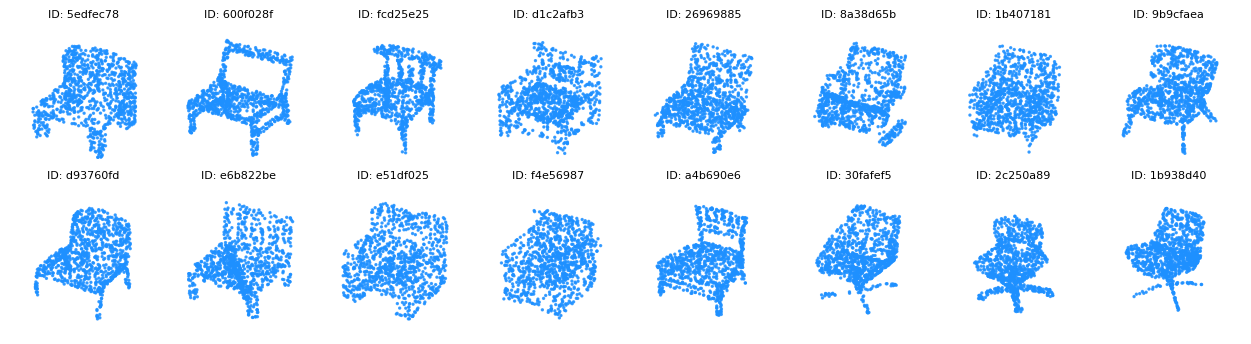

In [2]:
# raw mesh loader was very slow, precompute pointcloud as .npy instead
# dataset = ShapeNetDataset(data_dir='/ist/ist-share/scads/ploy/scene2/big_file/shapenet/shapenet/', object_class='03001627', num_points=1024)

dataset = ShapeNetDataset(data_dir='./sampled_poincloud/', object_class='03001627')
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

# plot 3d scatter of first batch
for batch in dataloader:
    pcs = batch['points']  # shape (B, N, 3)
    ids = batch['object_id']
    pc_list = list(zip(ids, pcs))
    plot_pointclouds(pc_list, n_cols=8)
    break

## Experiment Flow

- Define model and loss directly in this notebook for each experiment.
- Use `run_training(...)` from `experiment_runner.py` for training loop, checkpoints, metrics, tqdm, and optional wandb.

## Experiment List
- Baseline 1: Base model (no seed), Loss: Chamfer.
- Baseline 2: Base model (no seed), Loss: Chamfer + Repulsion.

## Setting up

In [3]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset
from model.base_model import PointCloudAE
from pytorch3d.loss import chamfer_distance
import numpy as np

from experiment_runner import ExperimentConfig, run_training

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# Shared configs for all runs
z_dim = 1024
batch_size = 16
num_epochs = 100
lr = 1e-3
val_split = 0.1
seed = 42

# Notebook-safe default: multiprocessing DataLoader workers can trigger
# "can only test a child process" cleanup errors in Jupyter.
num_workers = 0

torch.manual_seed(seed)
np.random.seed(seed)

num_points = dataset[0]["points"].shape[0]
all_indices = np.arange(len(dataset))
train_idx, val_idx = train_test_split(
    all_indices, test_size=val_split, random_state=seed, shuffle=True
)
train_set = Subset(dataset, train_idx)
val_set = Subset(dataset, val_idx)

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=num_workers,
    pin_memory=(device == "cuda"),
)
val_loader = DataLoader(
    val_set,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=(device == "cuda"),
)

/ist-nas/users/pratchp/conda_envs/pyt3d/lib/python3.10/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


device: cuda


Selecting diverse interpolation anchors:   0%|          | 0/678 [00:00<?, ?it/s]

Selecting diverse interpolation anchors:   0%|          | 0/678 [00:00<?, ?it/s]

Selecting diverse interpolation anchors:   0%|          | 0/678 [00:00<?, ?it/s]

Selected val_set local indices: [60, 439, 310, 592]
Selected dataset indices: [3289, 1670, 4959, 3904]
Selected object_ids: ['7a427785ad85f0c771c3cf047830ec1f', '48f0c9b02587b5a8ea0588dd0d874b1e', 'bb4f5cd713a817727d4f8900c5174db0', '920af478601258e24762da3a3017ade']


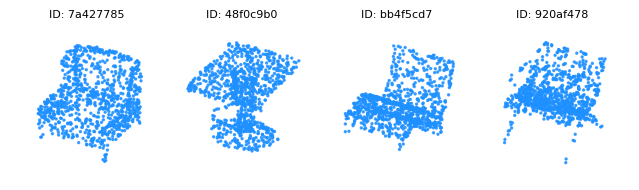

Created diverse_val_loader with 4 FPS-selected chairs.


In [4]:
# Select 4 maximally diverse validation chairs using shared helper
from utils.interpolation_anchors import build_diverse_anchor_loader

diverse_val_loader, diverse_local_idx, diverse_ids = build_diverse_anchor_loader(
    source_loader=val_loader,
    n_select=4,
    seed=seed,
    compute_device=device,
    show_progress=True,
)

# Map local val_set indices back to original dataset indices
diverse_dataset_idx = [int(val_idx[i]) for i in diverse_local_idx]

print("Selected val_set local indices:", diverse_local_idx)
print("Selected dataset indices:", diverse_dataset_idx)
print("Selected object_ids:", diverse_ids)

# Visual sanity check: these are the 4 anchors for hard interpolation.
anchor_batch = next(iter(diverse_val_loader))
diverse_pc_list = list(zip(anchor_batch["object_id"], anchor_batch["points"]))
plot_pointclouds(diverse_pc_list, n_cols=4)

print("Created diverse_val_loader with 4 FPS-selected chairs.")

## Baseline 1

In [5]:
import wandb
# wandb.login(key="")

In [6]:
# 1) Baseline experiment: Chamfer Distance only
model_cd = PointCloudAE(z_dim=z_dim, num_points=num_points)
optimizer_cd = torch.optim.Adam(model_cd.parameters(), lr=lr)
loss_fn_cd = lambda recon, points: chamfer_distance(
    recon.float(),
    points.float(),
    batch_reduction="mean",
    point_reduction="mean",
)[0]

cfg_cd = ExperimentConfig(
    name="baseline_cd_4interp",
    num_epochs=num_epochs,
    seed=seed,
    use_amp=True,
    save_every=10,
    run_root="/ist-nas/ist-share/vision/pratchp/shapevae_weights/",
    epoch_log_every=10,
)

run_dir_cd, summary_cd = run_training(
    config=cfg_cd,
    model=model_cd,
    optimizer=optimizer_cd,
    loss_fn=loss_fn_cd,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
)
print("Baseline CD run dir:", run_dir_cd)
print("Baseline CD summary:", summary_cd)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/pratch/.netrc.
wandb: Currently logged in as: alephnir (alephnir-vistec) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


[baseline_cd_4interp] interpolation anchors selected: idx=[60, 439, 310, 592], ids=['7a427785ad85f0c771c3cf047830ec1f', '48f0c9b02587b5a8ea0588dd0d874b1e', 'bb4f5cd713a817727d4f8900c5174db0', '920af478601258e24762da3a3017ade']


train:baseline_cd_4interp:   0%|          | 0/42500 [00:00<?, ?it/s]

[baseline_cd_4interp] epoch 10/100 train 0.004914 val 0.004972 best 0.004972
[baseline_cd_4interp] epoch 20/100 train 0.004114 val 0.004303 best 0.004303
[baseline_cd_4interp] epoch 30/100 train 0.003663 val 0.004123 best 0.004123
[baseline_cd_4interp] epoch 40/100 train 0.003394 val 0.003987 best 0.003965
[baseline_cd_4interp] epoch 50/100 train 0.003225 val 0.003928 best 0.003928
[baseline_cd_4interp] epoch 60/100 train 0.003101 val 0.003931 best 0.003918
[baseline_cd_4interp] epoch 70/100 train 0.003000 val 0.003928 best 0.003908
[baseline_cd_4interp] epoch 80/100 train 0.002939 val 0.003908 best 0.003866
[baseline_cd_4interp] epoch 90/100 train 0.002888 val 0.003904 best 0.003866
[baseline_cd_4interp] epoch 100/100 train 0.002823 val 0.003890 best 0.003866


epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇██
train/loss,█▆▆▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/best,█▆▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/loss,█▆▄▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_epoch,79
best_val,0.00387
epoch,100
run_dir,/ist-nas/ist-share/v...
train/loss,0.00282
val/best,0.00387
val/loss,0.00389


Baseline CD run dir: /ist-nas/ist-share/vision/pratchp/shapevae_weights/20260427-150616_pratch_baseline_cd_4interp
Baseline CD summary: {'best_val': 0.0038664220983898917, 'best_epoch': 79}


[reconstruction] unnormalize debug: showing 2 sample(s)
[reconstruction] sample=0 id=209994649e7fdf052ff84f70e18e9c53 norm_path=./sampled_poincloud/03001627/209994649e7fdf052ff84f70e18e9c53.norm.npz centroid=[ 0.00219346 -0.06998416  0.01934368] scale=0.4632846713066101
[reconstruction] sample=0 input min/max before=[-0.55446136 -0.5759433  -0.683938  ] / [0.5390002  0.85504335 0.4678463 ] after=[-0.25468    -0.33680987 -0.29751432] / [0.25190398 0.3261443  0.23608969]
[reconstruction] sample=0 recon min/max before=[-0.5003207  -0.6389278  -0.64090896] / [0.48215333 0.8783867  0.4460312 ] after=[-0.22959743 -0.36598963 -0.27757964] / [0.22556771 0.33695891 0.2259831 ]
[reconstruction] sample=1 id=71372c1f20b6a04c43c40c5aa3d5c5b7 norm_path=./sampled_poincloud/03001627/71372c1f20b6a04c43c40c5aa3d5c5b7.norm.npz centroid=[-0.00941562  0.21515355  0.07246429] scale=0.46718165278434753
[reconstruction] sample=1 input min/max before=[-0.4518644 -0.8922883 -0.6091761] / [0.48795372 0.7795543  

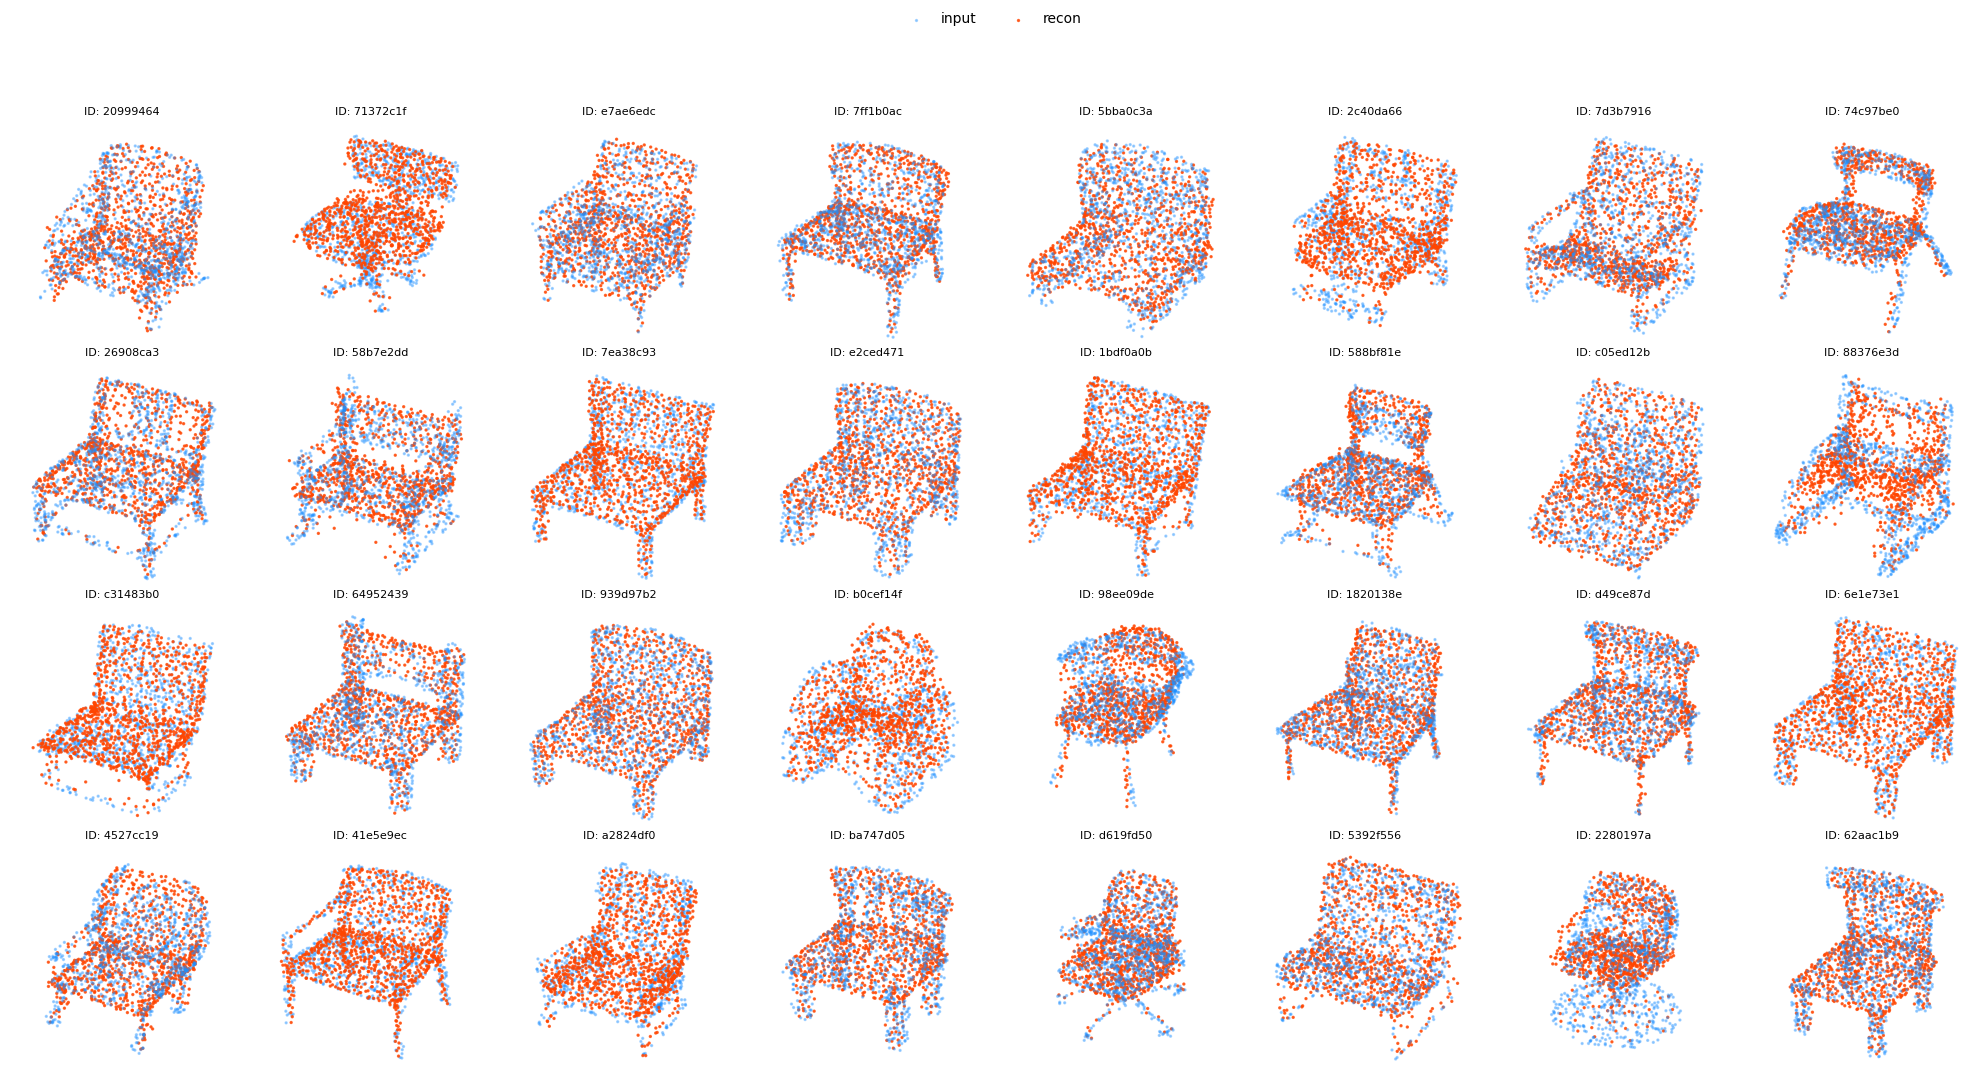

In [ ]:
# Visualize baseline reconstructions across N validation batches
visualize_reconstructions(
    model=model_cd,
    loader=val_loader,
    device=device,
    num_batches=2,
    n_cols=8,
    unnormalize=True,
)

In [ ]:
# 2) Baseline skeleton: Chamfer + Repulsion
# Keep model/optimizer definitions explicit; only loss changes.
model_rep = PointCloudAE(z_dim=z_dim, num_points=num_points)
optimizer_rep = torch.optim.Adam(model_rep.parameters(), lr=lr)

def repulsion_loss_placeholder(_pred_points):
    # TODO: implement your repulsion loss here.
    raise NotImplementedError("Implement repulsion loss before running this experiment")

def loss_fn_cd_plus_repulsion(recon, points):
    cd = chamfer_distance(
        recon,
        points,
        batch_reduction="mean",
        point_reduction="mean",
    )[0]
    rep = repulsion_loss_placeholder(recon)
    return cd + 0.1 * rep

cfg_cd_rep = ExperimentConfig(
    name="baseline_cd_plus_repulsion_skeleton",
    num_epochs=num_epochs,
    seed=seed,
    use_amp=True,
    save_every=10,
    run_root="runs",
)

print("Repulsion skeleton ready: implement repulsion_loss_placeholder, then uncomment run.")
# run_dir_rep, summary_rep = run_training(
#     config=cfg_cd_rep,
#     model=model_rep,
#     optimizer=optimizer_rep,
#     loss_fn=loss_fn_cd_plus_repulsion,
#     train_loader=train_loader,
#     val_loader=val_loader,
#     device=device,
# )